<a href="https://colab.research.google.com/github/matteotiraboschi13/grafici-r134a-fisica-tecnica/blob/main/Grafici_R134a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Configurazione iniziale**

Installo la libreria CoolProp che permette di calcolare le proprietà termodinamiche del fluido refrigerante R134a

In [201]:
!pip install CoolProp matplotlib numpy

Importo le librerie che verranno utilizzate successivamente.

In [202]:
import numpy as np # calcoli numerici
import matplotlib.pyplot as plt # grafici
import CoolProp.CoolProp as CP # proprietà termodinamiche

# **Calcolo proprietà**

In [203]:
fluid = "R134a" # fluido refrigerante

Imposto il riferimento ASHRAE, ovvero una scelta dello zero da usare per leggere entalpia ed entropia.

In [204]:
CP.set_reference_state(fluid, "ASHRAE") # riferimento coerente con le tabelle

Calcolo della temperatura critica del fluido refrigerante R134a.

In [205]:
Tcrit = CP.PropsSI("Tcrit", fluid) # temperatura critica [K]

Creo un vettore di 400 temperature comprese tra $-40\,^\circ\mathrm{C}$ e $T_{\mathrm{crit}}$.

In [206]:
T = np.linspace(-40 + 273.15, Tcrit, 400) # temperature da -40°C a Tcrit

Creo dei vettori vuoti, pieni di Nan da riempire con le proprietà del R134a.

In [207]:
sL = np.full_like(T, np.nan) # entropia liquido saturo
sV = np.full_like(T, np.nan) # entropia vapore saturo
vL = np.full_like(T, np.nan) # volume liquido saturo
vV = np.full_like(T, np.nan) # volume vapore saturo
pSat = np.full_like(T, np.nan) # pressione di saturazione

Riempio i vettori creati in precedenza calcolando le proprietà del R134a per ogni temperatura del vettore T.

In [208]:
for i in range(len(T)):
    sL[i] = CP.PropsSI("Smass", "T", T[i], "Q", 0, fluid) / 1000 # kJ/(kg K)
    sV[i] = CP.PropsSI("Smass", "T", T[i], "Q", 1, fluid) / 1000 # kJ/(kg K)
    vL[i] = 1 / CP.PropsSI("Dmass", "T", T[i], "Q", 0, fluid) # m^3/kg
    vV[i] = 1 / CP.PropsSI("Dmass", "T", T[i], "Q", 1, fluid) # m^3/kg
    pSat[i] = CP.PropsSI("P", "T", T[i], "Q", 0, fluid) / 1e5 # bar

# **Grafico T-s**

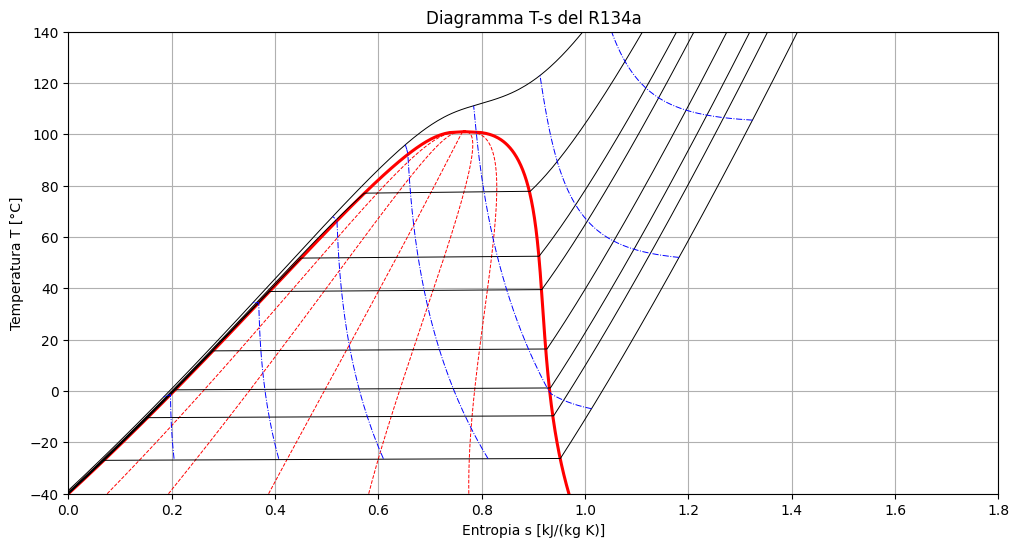

In [213]:
plt.figure(figsize=(12, 6)) # creo figura
plt.grid(True) # attivo griglia
plt.box(True) # attivo riquadro

plt.plot(sL, T - 273.15, "r", linewidth=2.2) # curva liquido saturo
plt.plot(sV, T - 273.15, "r", linewidth=2.2) # curva vapore saturo

for x in [0.0775, 0.2, 0.4, 0.6, 0.8]:
    sx = sL + x * (sV - sL) # legge della leva
    plt.plot(sx, T - 273.15, "r--", linewidth=0.7) # curve del titolo

for pbar in [1, 2, 3, 5, 10, 14, 25, 50]:
    P = pbar * 1e5
    TT = np.linspace(-40 + 273.15, 140 + 273.15, 250)
    ss = np.full_like(TT, np.nan)

    for k in range(len(TT)):
        try:
            ss[k] = CP.PropsSI("Smass", "T", TT[k], "P", P, fluid) / 1000
        except:
            ss[k] = np.nan

    plt.plot(ss, TT - 273.15, "k", linewidth=0.7) # isobare

for h_kJkg in [50,100,150, 200, 250, 300, 350]:
    h = h_kJkg * 1000
    PP = np.linspace(1e5, 50e5, 250) # pressione da 1 bar a 50 bar
    TT = np.full_like(PP, np.nan) # temperatura
    ss = np.full_like(PP, np.nan) # entropia

    for k in range(len(PP)):
        try:
            TT[k] = CP.PropsSI("T", "P", PP[k], "Hmass", h, fluid)
            ss[k] = CP.PropsSI("Smass", "P", PP[k], "Hmass", h, fluid) / 1000
        except:
            pass

    plt.plot(ss, TT - 273.15, "b-.", linewidth=0.7) # isoentalpiche

plt.xlabel("Entropia s [kJ/(kg K)]")
plt.ylabel("Temperatura T [°C]")
plt.title("Diagramma T-s del R134a")
plt.xlim(0, 1.8)
plt.ylim(-40, 140)
plt.show()

# **Grafico p-v**

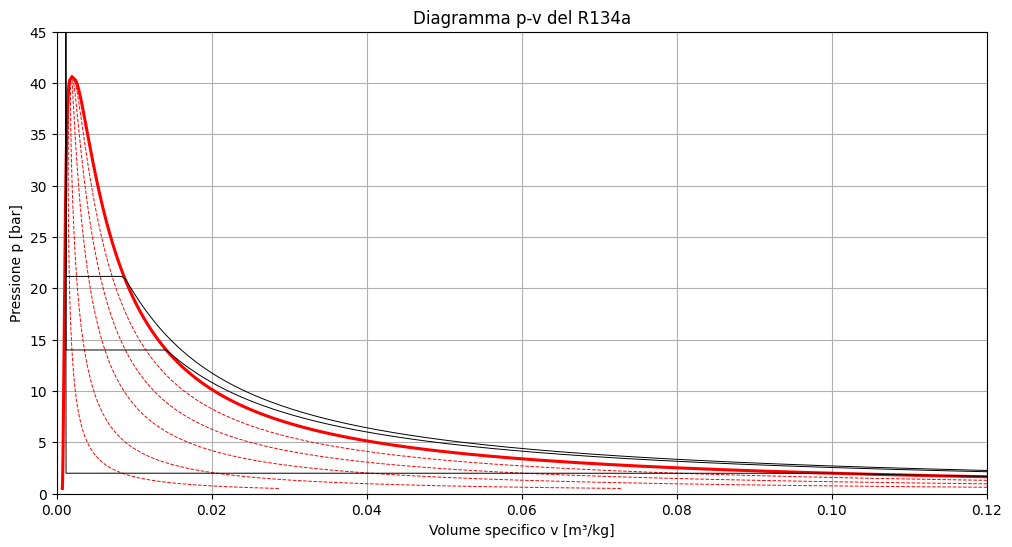

In [215]:
plt.figure(figsize=(12, 6)) # creo figura
plt.grid(True) # attivo griglia
plt.box(True) # attivo riquadro

plt.plot(vL, pSat, "r", linewidth=2.2) # curva liquido saturo
plt.plot(vV, pSat, "r", linewidth=2.2) # curva vapore saturo

for x in [0.0775, 0.2, 0.4, 0.6, 0.8]:
    vx = vL + x * (vV - vL) # legge della leva sul volume
    plt.plot(vx, pSat, "r--", linewidth=0.7) # curve del titolo

for TC in [-10.09, 52.43, 70]:
    TT = TC + 273.15
    vv = np.linspace(0.0007, 0.12, 250)
    pp = np.full_like(vv, np.nan)

    for k in range(len(vv)):
            pp[k] = CP.PropsSI("P", "T", TT, "Dmass", 1 / vv[k], fluid) / 1e5


    plt.plot(vv, pp, "k", linewidth=0.7) # isoterme


plt.xlabel("Volume specifico v [m³/kg]")
plt.ylabel("Pressione p [bar]")
plt.title("Diagramma p-v del R134a")
plt.xlim(0, 0.12)
plt.ylim(0, 45)
plt.show()

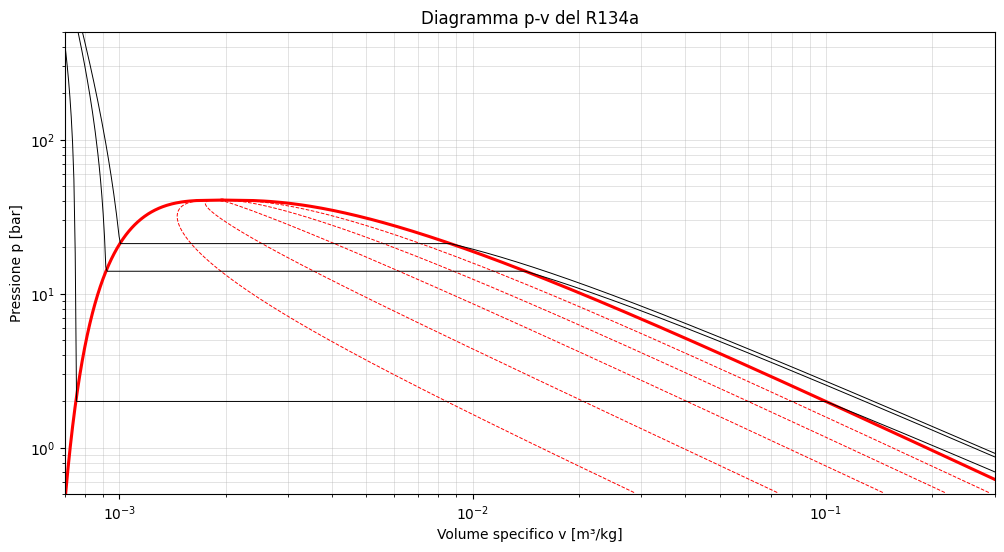

In [217]:
plt.figure(figsize=(12, 6)) # creo figura
plt.grid(True, which="both", linewidth=0.5, alpha=0.5)
plt.box(True) # attivo riquadro

plt.plot(vL, pSat, "r", linewidth=2.2) # curva liquido saturo
plt.plot(vV, pSat, "r", linewidth=2.2) # curva vapore saturo

for x in [0.0775, 0.2, 0.4, 0.6, 0.8]:
    vx = vL + x * (vV - vL) # legge della leva sul volume
    plt.plot(vx, pSat, "r--", linewidth=0.7) # curve del titolo

for TC in [-10.09, 52.43, 70]:
    TT = TC + 273.15
    vv = np.logspace(np.log10(0.0007), np.log10(0.30), 700)
    pp = np.full_like(vv, np.nan)

    for k in range(len(vv)):
        try:
            pp[k] = CP.PropsSI("P", "T", TT, "Dmass", 1 / vv[k], fluid) / 1e5 # pressione in bar
        except:
            pp[k] = np.nan

    plt.plot(vv, pp, "k", linewidth=0.7) # isoterme


plt.xscale("log") # asse volume logaritmico
plt.yscale("log") # asse pressione logaritmico

plt.xlabel("Volume specifico v [m³/kg]")
plt.ylabel("Pressione p [bar]")
plt.title("Diagramma p-v del R134a")

plt.xlim(0.0007, 0.3) # non posso partire da 0 con asse log
plt.ylim(0.5, 500) # non posso partire da 0 con asse log

plt.show()

# **Rappresentazione degli stati termodinamici**

Assegniamo alle variabili i nostri punti calcolati dalle tabelle del R134a.

In [218]:
T1_C = -5.00                 # temperatura punto 1 [°C]
T2_C = 70.00                 # temperatura punto 2 [°C]
T3_C = 2.00                  # temperatura punto 3 [°C]
T4_C = -10.09                # temperatura punto 4 [°C]

P1_bar = 2                   # pressione punto 1 [bar]
P2_bar = 14                  # pressione punto 2 [bar]
P3_bar = 14                  # pressione punto 3 [bar]
P4_bar = 2                   # pressione punto 4 [bar]

s1 = 0.9419                  # entropia punto 1 [kJ/(kg K)]
s2 = 0.9658                  # entropia punto 2 [kJ/(kg K)]
s3 = 0.2066                  # entropia punto 3 [kJ/(kg K)]
s4 = 0.2083                  # entropia punto 4 [kJ/(kg K)]

v1 = 0.10188                 # volume specifico punto 1 [m³/kg]
v2 = 0.01603                 # volume specifico punto 2 [m³/kg]
v3 = 0.0007761               # volume specifico punto 3 [m³/kg]
v4 = 0.00838                 # volume specifico punto 4 [m³/kg]

In [219]:
v_points = [v1, v2, v3, v4]                  # volumi specifici dei punti [m³/kg]
p_points = [P1_bar, P2_bar, P3_bar, P4_bar]  # pressioni dei punti [bar]

In [220]:
s_points = [s1, s2, s3, s4]                  # entropie dei punti [kJ/(kg K)]
T_points = [T1_C, T2_C, T3_C, T4_C]          # temperature dei punti [°C]

Mostriamo ora i punti sul grafico T-s.

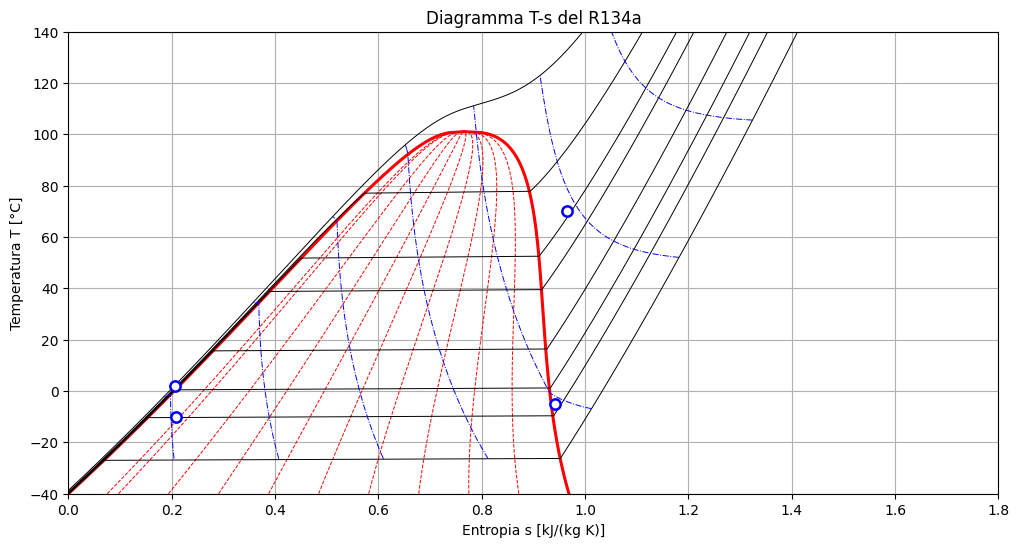

In [221]:
plt.figure(figsize=(12, 6)) # creo figura
plt.grid(True) # attivo griglia
plt.box(True) # attivo riquadro

plt.plot(sL, T - 273.15, "r", linewidth=2.2) # curva liquido saturo
plt.plot(sV, T - 273.15, "r", linewidth=2.2) # curva vapore saturo

for x in [0.0775,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    sx = sL + x * (sV - sL) # legge della leva
    plt.plot(sx, T - 273.15, "r--", linewidth=0.7) # curve del titolo

for pbar in [1, 2, 3, 5, 10, 14, 25, 50]:
    P = pbar * 1e5
    TT = np.linspace(-40 + 273.15, 140 + 273.15, 250)
    ss = np.full_like(TT, np.nan)

    for k in range(len(TT)):
        try:
            ss[k] = CP.PropsSI("Smass", "T", TT[k], "P", P, fluid) / 1000
        except:
            ss[k] = np.nan

    plt.plot(ss, TT - 273.15, "k", linewidth=0.7) # isobare

for h_kJkg in [50,100,150, 200, 250, 300, 350]:
    h = h_kJkg * 1000
    PP = np.linspace(1e5, 50e5, 250) # pressione da 1 bar a 50 bar
    TT = np.full_like(PP, np.nan) # temperatura
    ss = np.full_like(PP, np.nan) # entropia

    for k in range(len(PP)):
        try:
            TT[k] = CP.PropsSI("T", "P", PP[k], "Hmass", h, fluid)
            ss[k] = CP.PropsSI("Smass", "P", PP[k], "Hmass", h, fluid) / 1000
        except:
            pass

    plt.plot(ss, TT - 273.15, "b-.", linewidth=0.7) # isoentalpiche


plt.scatter(s_points, T_points,s=55,marker="o",facecolors="white",edgecolors="blue",linewidths=1.8,zorder=10)

plt.xlabel("Entropia s [kJ/(kg K)]")
plt.ylabel("Temperatura T [°C]")
plt.title("Diagramma T-s del R134a")
plt.xlim(0, 1.8)
plt.ylim(-40, 140)
plt.show()

Mostriamo ora i punti sul grafico p-v.

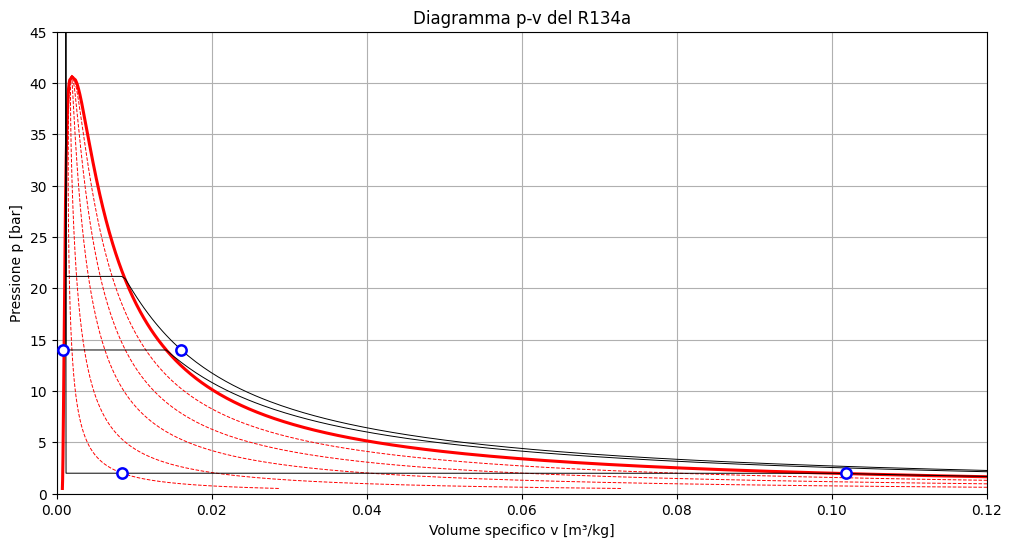

In [198]:
plt.figure(figsize=(12, 6)) # creo figura
plt.grid(True) # attivo griglia
plt.box(True) # attivo riquadro

plt.plot(vL, pSat, "r", linewidth=2.2) # curva liquido saturo
plt.plot(vV, pSat, "r", linewidth=2.2) # curva vapore saturo

for x in [0.0775, 0.2, 0.4, 0.6, 0.8]:
    vx = vL + x * (vV - vL) # legge della leva sul volume
    plt.plot(vx, pSat, "r--", linewidth=0.7) # curve del titolo

for TC in [-10.09, 52.43, 70]:
    TT = TC + 273.15
    vv = np.linspace(0.0007, 0.12, 250)
    pp = np.full_like(vv, np.nan)

    for k in range(len(vv)):
            pp[k] = CP.PropsSI("P", "T", TT, "Dmass", 1 / vv[k], fluid) / 1e5


    plt.plot(vv, pp, "k", linewidth=0.7) # isoterme


# punti del ciclo
plt.scatter(v_points, p_points,s=55,marker="o",facecolors="white",edgecolors="blue",linewidths=1.8,zorder=10)
plt.xlabel("Volume specifico v [m³/kg]")
plt.ylabel("Pressione p [bar]")
plt.title("Diagramma p-v del R134a")
plt.xlim(0, 0.12)
plt.ylim(0, 45)
plt.show()

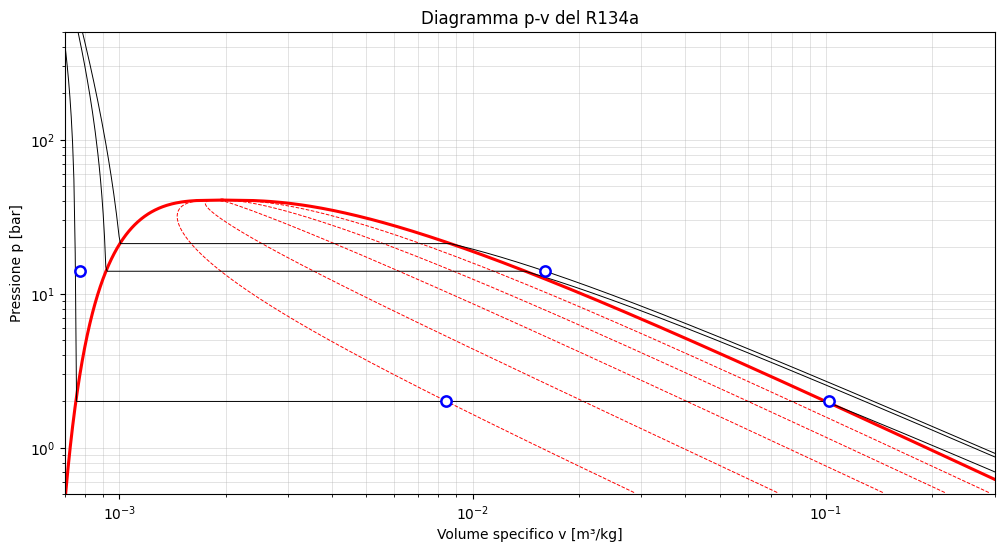

In [199]:
plt.figure(figsize=(12, 6)) # creo figura
plt.grid(True, which="both", linewidth=0.5, alpha=0.5)
plt.box(True) # attivo riquadro

plt.plot(vL, pSat, "r", linewidth=2.2) # curva liquido saturo
plt.plot(vV, pSat, "r", linewidth=2.2) # curva vapore saturo

for x in [0.0775, 0.2, 0.4, 0.6, 0.8]:
    vx = vL + x * (vV - vL) # legge della leva sul volume
    plt.plot(vx, pSat, "r--", linewidth=0.7) # curve del titolo

for TC in [-10.09, 52.43, 70]:
    TT = TC + 273.15
    vv = np.logspace(np.log10(0.0007), np.log10(0.30), 700)
    pp = np.full_like(vv, np.nan)

    for k in range(len(vv)):
        try:
            pp[k] = CP.PropsSI("P", "T", TT, "Dmass", 1 / vv[k], fluid) / 1e5 # pressione in bar
        except:
            pp[k] = np.nan

    plt.plot(vv, pp, "k", linewidth=0.7) # isoterme

# punti del ciclo
plt.scatter(v_points, p_points,s=55,marker="o",facecolors="white",edgecolors="blue",linewidths=1.8,zorder=10)

plt.xscale("log") # asse volume logaritmico
plt.yscale("log") # asse pressione logaritmico
plt.xlabel("Volume specifico v [m³/kg]")
plt.ylabel("Pressione p [bar]")
plt.title("Diagramma p-v del R134a")
plt.xlim(0.0007, 0.3) # non posso partire da 0 con asse log
plt.ylim(0.5, 500) # non posso partire da 0 con asse log

plt.show()